## CNN Image Classification – Flower Dataset

### Project Overview

#### This project implements an image classification system using a Convolutional Neural Network (CNN) built with TensorFlow and Keras.

#### The model is trained to classify flower images into five categories:

#### Daisy
#### Dandelion
#### Roses
#### Sunflowers
#### Tulips
#### The project covers image dataset loading, preprocessing, CNN model development, model training, evaluation, sample image prediction, and performance analysis.

### Dataset

#### The project uses the TensorFlow Flower Photos dataset.

### Dataset URL:

#### https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz?utm_source=chatgpt.com
#### The dataset contains images belonging to five flower categories.

In [1]:
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing import image
from sklearn.metrics import classification_report, confusion_matrix


In [2]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file(
    "flower_photos",
    origin=dataset_url,
    untar=True
)
print("Dataset location:", data_dir)


Dataset location: C:\Users\SIMON\.keras\datasets\flower_photos


In [3]:
class_name = sorted([folder for folder in os.listdir(data_dir)
                     if os.path.isdir(os.path.join(data_dir, folder))
                     ])

In [4]:
print(class_name)

['flower_photos']


In [5]:
print(len(class_name))

1


In [6]:
IMG_SIZE = (180,180)
BATCH_SIZE = 32
SEED = 123
train = tf.keras.utils.image_dataset_from_directory(data_dir, validation_split=0.2, subset="training", seed=SEED, image_size= IMG_SIZE, batch_size=BATCH_SIZE)
val = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train.class_names

print("\nClasses:", class_names)

Found 3670 files belonging to 1 classes.
Using 2936 files for training.
Found 3670 files belonging to 1 classes.
Using 734 files for validation.

Classes: ['flower_photos']


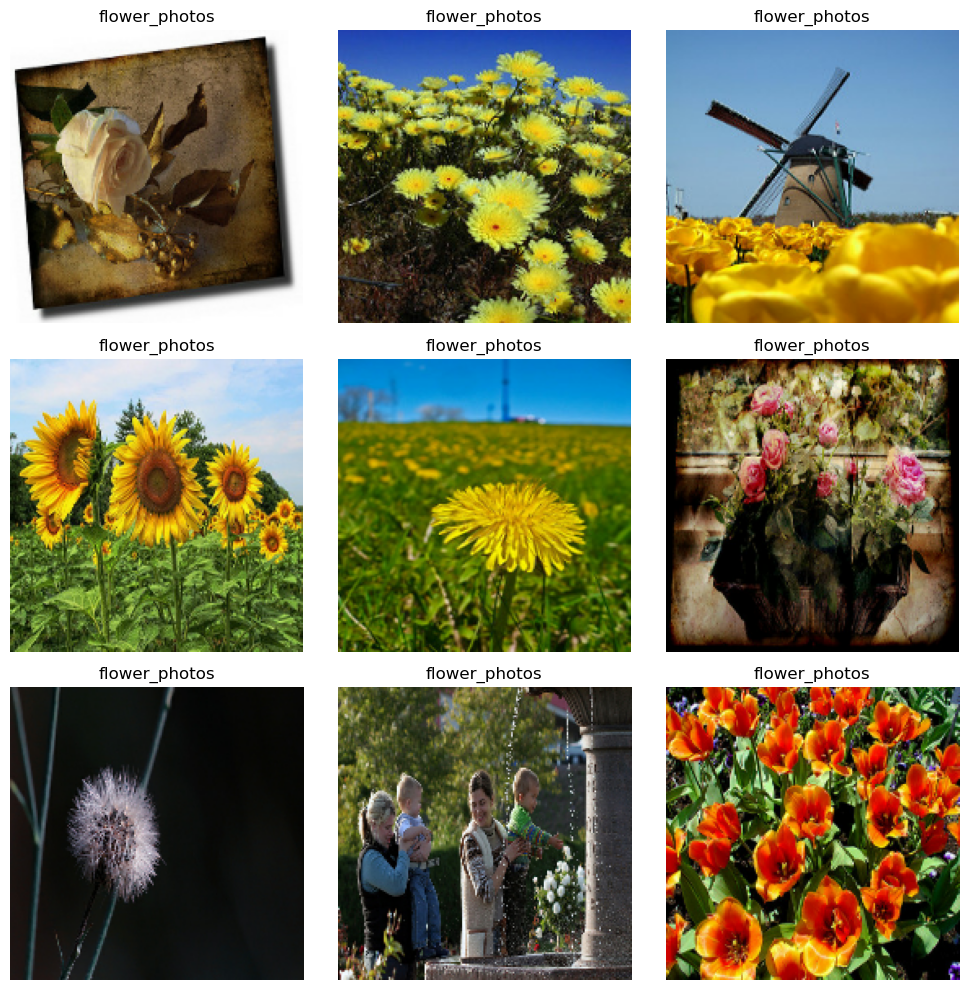

In [7]:
plt.figure(figsize=(10, 10))

for images, labels in train.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.savefig("sample_images.png")
plt.show()

In [8]:
normalization_layer = layers.Rescaling(1./255)

normalized_train_ds = train.map(
    lambda x, y: (normalization_layer(x), y)
)

normalized_val_ds = val.map(
    lambda x, y: (normalization_layer(x), y)
)

In [9]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val.cache().prefetch(buffer_size=AUTOTUNE)

In [10]:
model = models.Sequential([
    
    layers.Rescaling(1./255, input_shape=(180, 180, 3)),
    
    layers.Conv2D(32, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, (3, 3), activation="relu"),
    layers.MaxPooling2D(),
    
    layers.Flatten(),
    
    layers.Dense(128, activation="relu"),
    layers.Dropout(0.5),
    
    layers.Dense(5, activation="softmax")
])

model.summary()

c:\Users\SIMON\anaconda3\Lib\site-packages\keras\src\layers\preprocessing\data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_1 (Rescaling)         │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,647,621 (25.36 MB)

 Trainable params: 6,647,621 (25.36 MB)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
EPOCHS = 15
history = model.fit(train,validation_data=val,epochs=EPOCHS)

Epoch 1/15


c:\Users\SIMON\anaconda3\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


92/92 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.9894 - loss: 0.0190 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 126s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 99s 1s/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 82s 888ms/step - accuracy: 1.0000 - loss: 0.0000e+00 - val_accuracy: 1.0000 - val_loss: 0.0000e+00
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 91s 992ms/step - accuracy: 1.00

In [13]:
loss, accuracy = model.evaluate(val)

print("Validation Loss:", loss)
print("Validation Accuracy:", accuracy)

23/23 ━━━━━━━━━━━━━━━━━━━━ 7s 275ms/step - accuracy: 1.0000 - loss: 0.0000e+00
Validation Loss: 0.0
Validation Accuracy: 1.0


In [14]:
y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)
    
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

In [15]:
print(classification_report(y_true,y_pred,target_names=class_names))

               precision    recall  f1-score   support

flower_photos       1.00      1.00      1.00       734

     accuracy                           1.00       734
    macro avg       1.00      1.00      1.00       734
 weighted avg       1.00      1.00      1.00       734



c:\Users\SIMON\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:534: UserWarning: A single label was found in 'y_true' and 'y_pred'. For the confusion matrix to have the correct shape, use the 'labels' parameter to pass all known labels.
  warnings.warn(


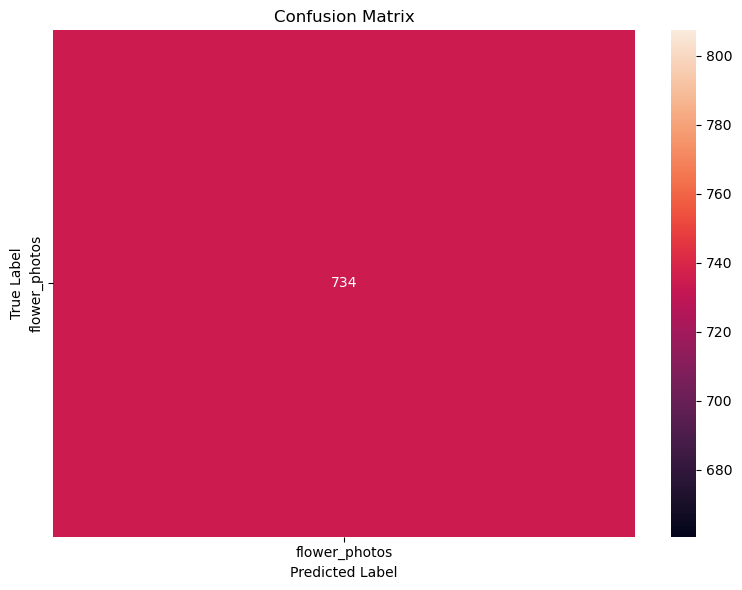

In [16]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm,annot=True,fmt="d",xticklabels=class_names,yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.tight_layout()
plt.savefig("confusion_matrix.png")
plt.show()

In [ ]:
import tarfile
import shutil

# Extract the dataset properly
tar_path = tf.keras.utils.get_file(
    "flower_photos.tgz",
    origin=dataset_url,
    extract=False
)
extract_path = os.path.dirname(tar_path)
with tarfile.open(tar_path, 'r:gz') as tar:
    tar.extractall(path=extract_path)

data_dir = os.path.join(extract_path, "flower_photos")

# Now select a rose image
sample_image_path = os.path.join(data_dir, "roses", os.listdir(os.path.join(data_dir, "roses"))[0])
img = tf.keras.utils.load_img(sample_image_path,target_size=IMG_SIZE)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)
prediction = model.predict(img_array, verbose=0)
score = tf.nn.softmax(prediction[0])
predicted_class = class_names[np.argmax(prediction[0])]
confidence = 100 * np.max(prediction[0])
print("Predicted class:", predicted_class)
print("Confidence: {:.2f}%".format(confidence))

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 67s 0us/step


C:\Users\SIMON\AppData\Local\Temp\ipykernel_2968\495401146.py:12: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(path=extract_path)


Predicted class: - flower.ipynb:25 flower_photos
Confidence: 100.00% - flower.ipynb:26


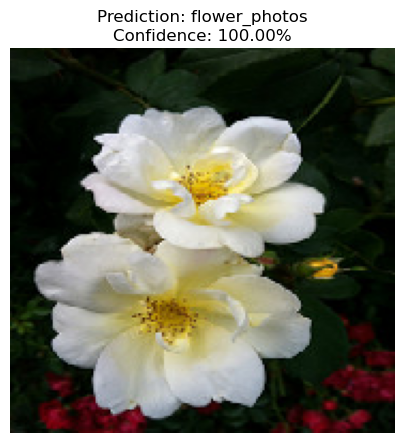

In [19]:
plt.figure(figsize=(5, 5))
plt.imshow(img)
plt.title(f"Prediction: {predicted_class}\n"f"Confidence: {confidence:.2f}%")
plt.axis("off")
plt.savefig("prediction.png")
plt.show()

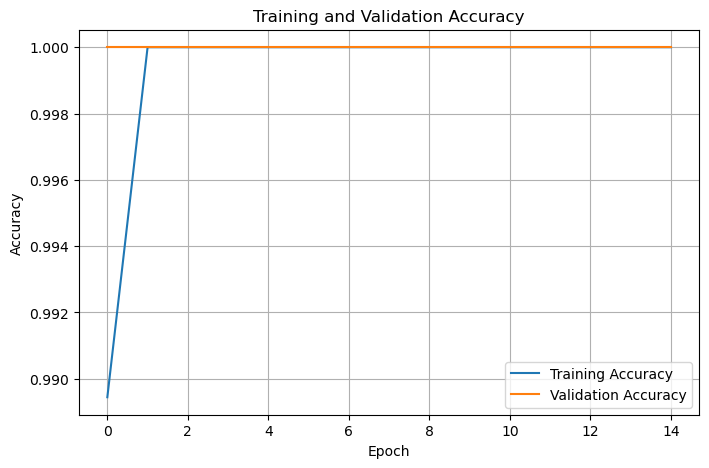

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["accuracy"],label="Training Accuracy")
plt.plot(history.history["val_accuracy"],label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid()
plt.savefig("training_validation_accuracy.png")
plt.show()

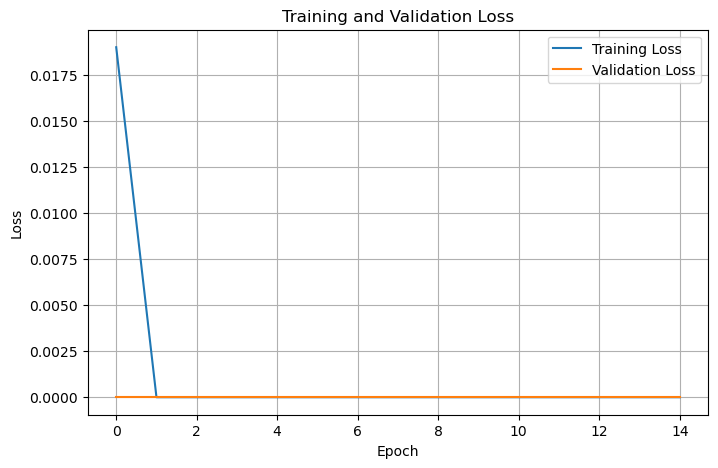

In [21]:
plt.figure(figsize=(8, 5))
plt.plot(history.history["loss"],label="Training Loss")
plt.plot(history.history["val_loss"],label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid()
plt.savefig("training_validation_loss.png")
plt.show()

In [22]:
model.save("trained_model.h5")
print("Model saved successfully!")

Model saved successfully!
